# Credit Card Fraud Detection — Model Training & Comparison

Bu notebook 3 modeli (Logistic Regression, Random Forest, XGBoost) eğitir ve karşılaştırır.  
Ardından en iyi modeli Optuna ile hiperparametre optimizasyonuna tabi tutar.

**İçerik:**
1. Veri Yükleme
2. Model Eğitimi & Loss Curves
3. Confusion Matrix (Validation + Test)
4. Classification Report (Precision, Recall, F1 — Fraud odaklı)
5. ROC-AUC Curves (birleşik + ayrı)
6. Precision-Recall Curves
7. Threshold Optimization
8. Optuna Bayesian Hyperparameter Optimization
9. Optimized Model Evaluation
10. Final Comparison

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import classification_report, accuracy_score, f1_score
import optuna  # type: ignore

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Add project root to path for training.py imports
PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from training import (
    load_data,
    plot_confusion_matrices, print_classification_report_custom,
    compute_roc_pr, find_best_threshold, plot_f1_vs_threshold,
    train_logistic_regression_with_loss, train_random_forest_with_loss,
    train_xgboost_with_loss, plot_loss_curves,
    plot_roc_combined, plot_roc_individual,
    plot_pr_combined, plot_pr_individual,
    run_optuna_optimization, train_optimized_model,
    build_summary_table, OUTPUT_DIR
)

print('All imports OK')

c:\Users\gktng\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


## 1. Veri Yükleme

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, features = load_data()

print(f"\nFeatures ({len(features)}): {features[:5]} ... {features[-5:]}")
print(f"\nTrain class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val   class distribution: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test  class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")

Train : (398040, 35)  | Fraud ratio: 0.5000
Val   : (42721, 35)  | Fraud ratio: 0.0017
Test  : (42722, 35)  | Fraud ratio: 0.0017

Features (35): ['Time', 'V1', 'V2', 'V3', 'V4'] ... ['Time_in_day', 'Amount_log', 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']

Train class distribution: {np.int64(0): np.int64(199020), np.int64(1): np.int64(199020)}
Val   class distribution: {np.int64(0): np.int64(42647), np.int64(1): np.int64(74)}
Test  class distribution: {np.int64(0): np.int64(42648), np.int64(1): np.int64(74)}


---
## 2. Model Eğitimi & Loss Curves

### 2.1 Logistic Regression (Baseline)
- `solver='saga'`, `warm_start=True` ile iterasyon bazlı log_loss takibi

Training Logistic Regression...
    LR checkpoint iter=5 done
    LR checkpoint iter=10 done
    LR checkpoint iter=25 done
    LR checkpoint iter=50 done
    LR checkpoint iter=100 done
    LR checkpoint iter=200 done
  Logistic Regression trained (final iter=200)


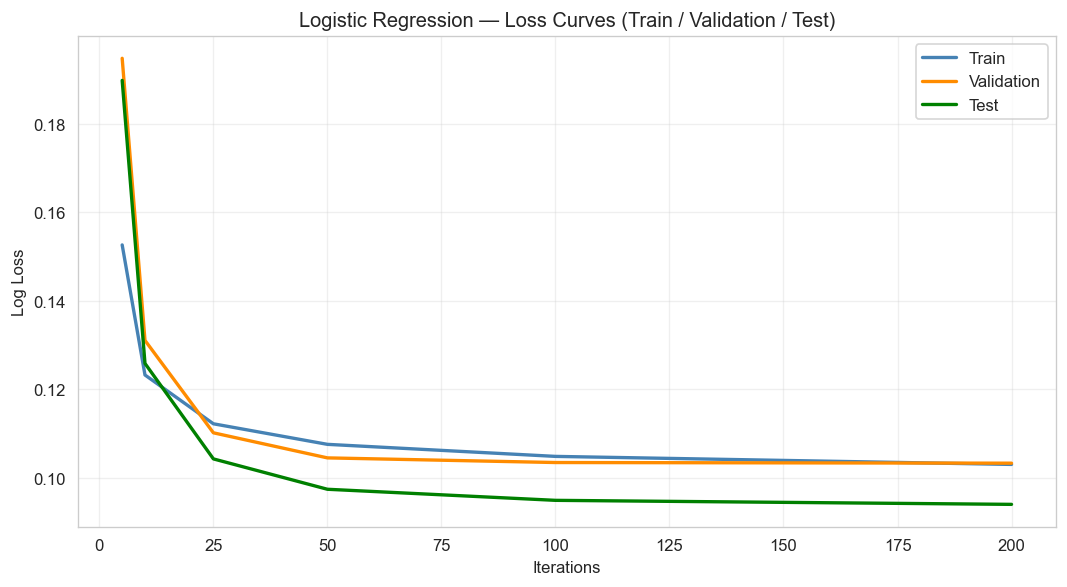

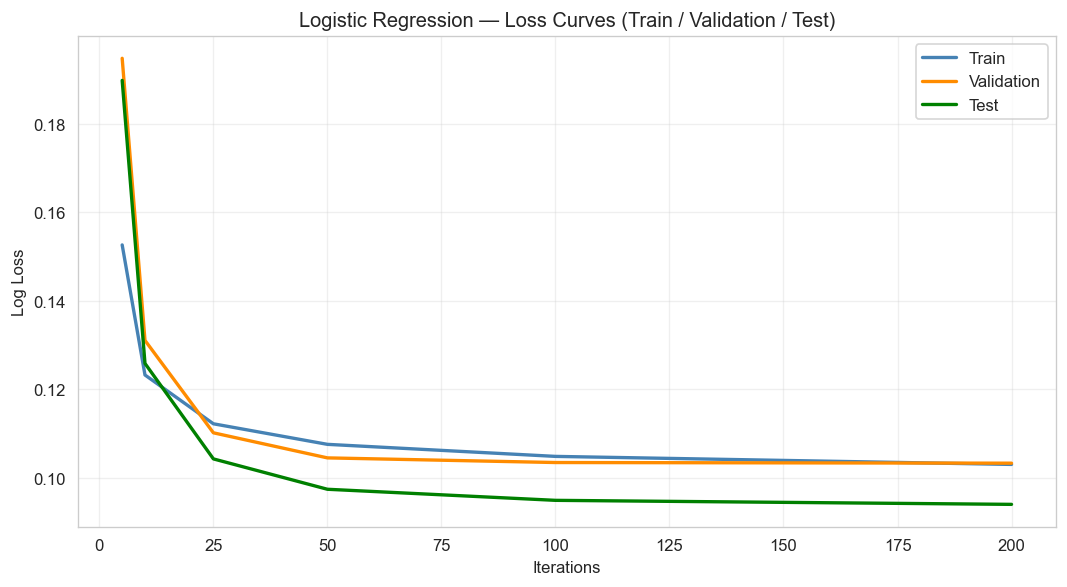

In [3]:
print("Training Logistic Regression...")
lr_model, lr_losses = train_logistic_regression_with_loss(
    X_train, y_train, X_val, y_val, X_test, y_test
)
plot_loss_curves(lr_losses, 'iters', 'Iterations', 'Logistic Regression', save=True)

### 2.2 Random Forest
- `warm_start=True` ile kademeli n_estimators artışı, her aşamada log_loss kaydı

Training Random Forest...
    RF checkpoint n_estimators=10 done
    RF checkpoint n_estimators=25 done
    RF checkpoint n_estimators=50 done
    RF checkpoint n_estimators=75 done
    RF checkpoint n_estimators=100 done
    RF checkpoint n_estimators=150 done
    RF checkpoint n_estimators=200 done
  Random Forest trained (n_estimators=200)


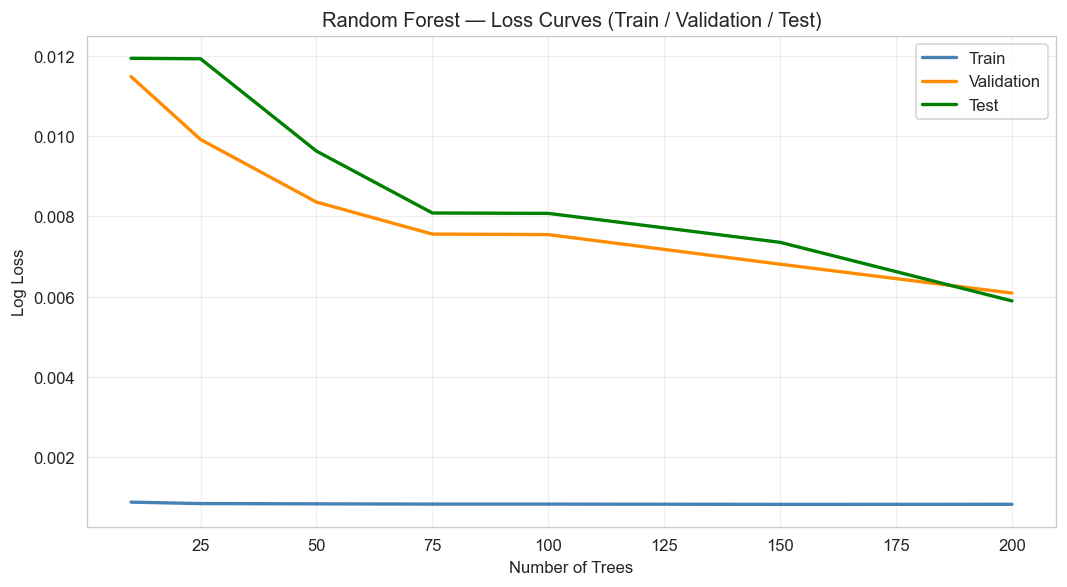

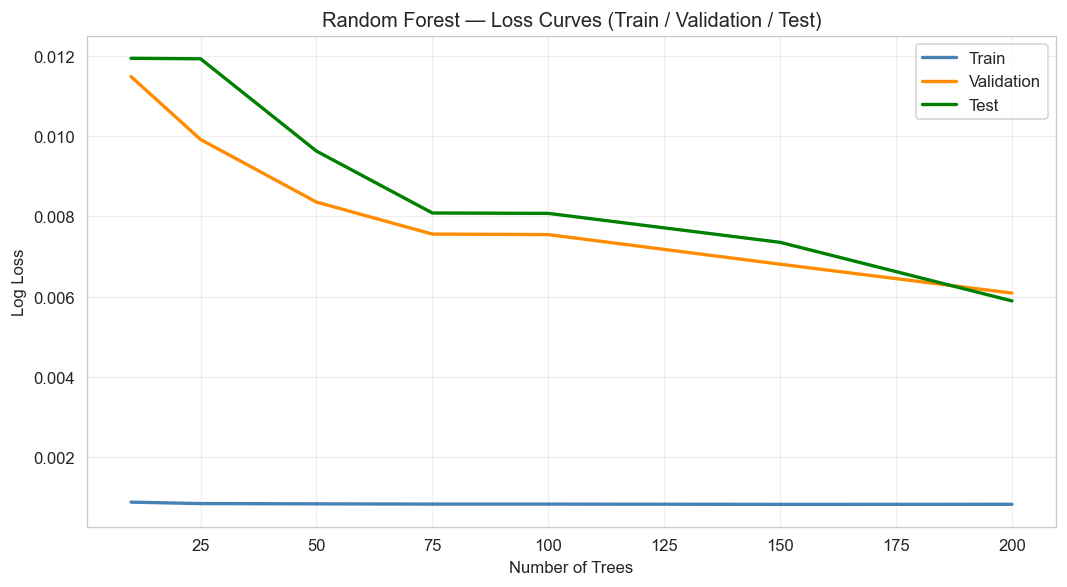

In [4]:
print("Training Random Forest...")
rf_model, rf_losses = train_random_forest_with_loss(
    X_train, y_train, X_val, y_val, X_test, y_test
)
plot_loss_curves(rf_losses, 'n_estimators', 'Number of Trees', 'Random Forest', save=True)

### 2.3 XGBoost
- `eval_set` ile native train/val/test logloss per boosting round

Training XGBoost...
  XGBoost trained (n_estimators=200)


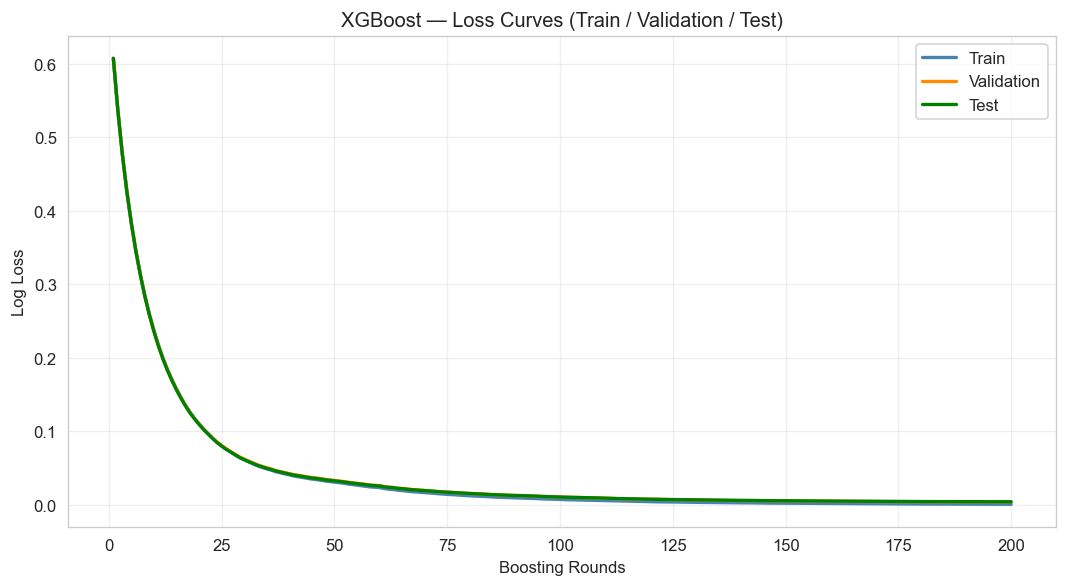

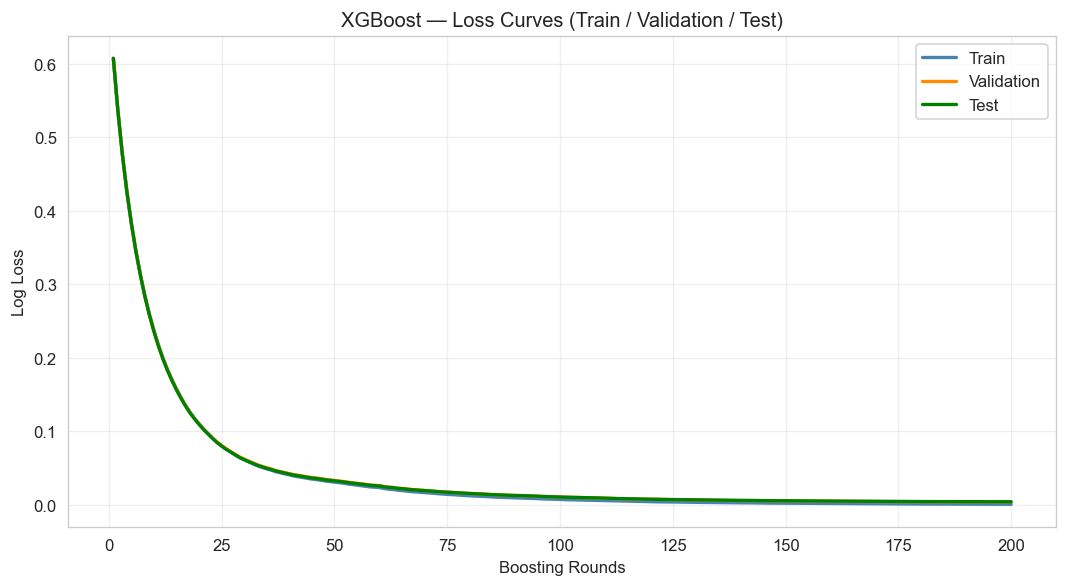

In [5]:
print("Training XGBoost...")
xgb_model, xgb_losses = train_xgboost_with_loss(
    X_train, y_train, X_val, y_val, X_test, y_test
)
plot_loss_curves(xgb_losses, 'rounds', 'Boosting Rounds', 'XGBoost', save=True)

In [6]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}
print("All 3 models trained successfully.")

All 3 models trained successfully.


---
## 3. Confusion Matrix (Validation + Test)

Her model için validation ve test seti confusion matrix'leri yan yana gösterilir.

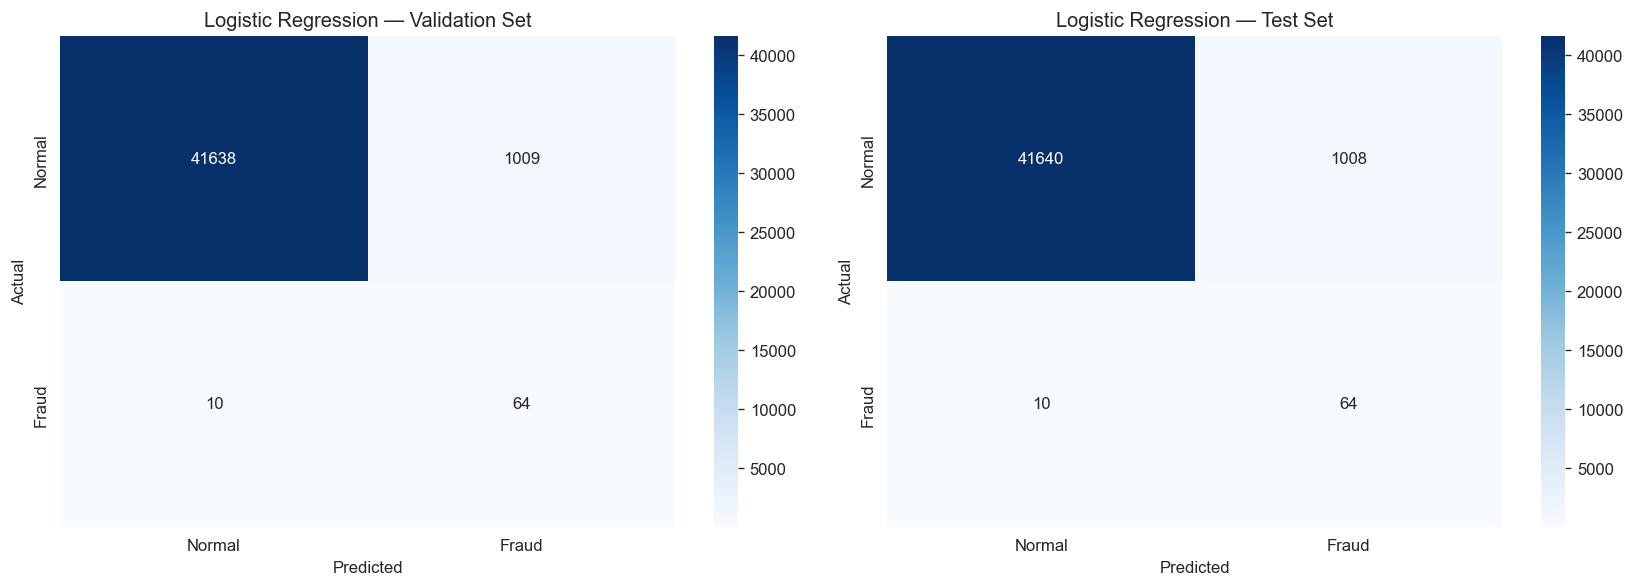

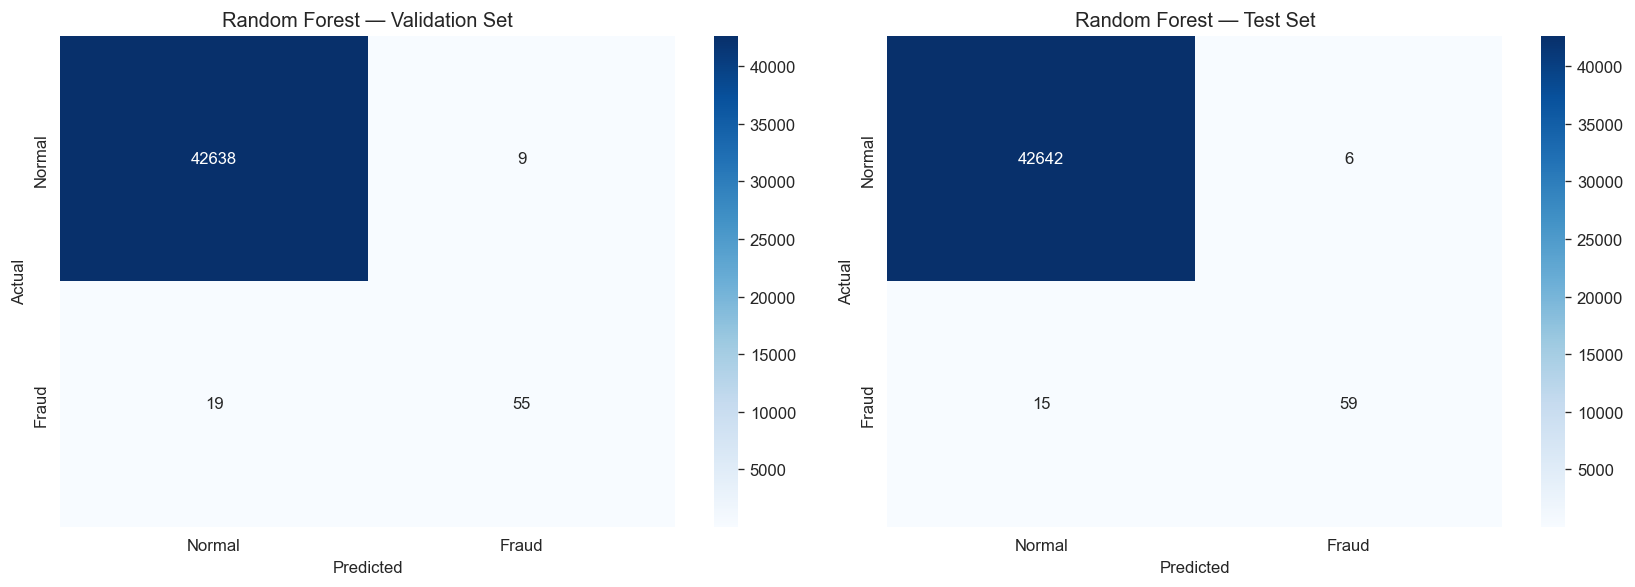

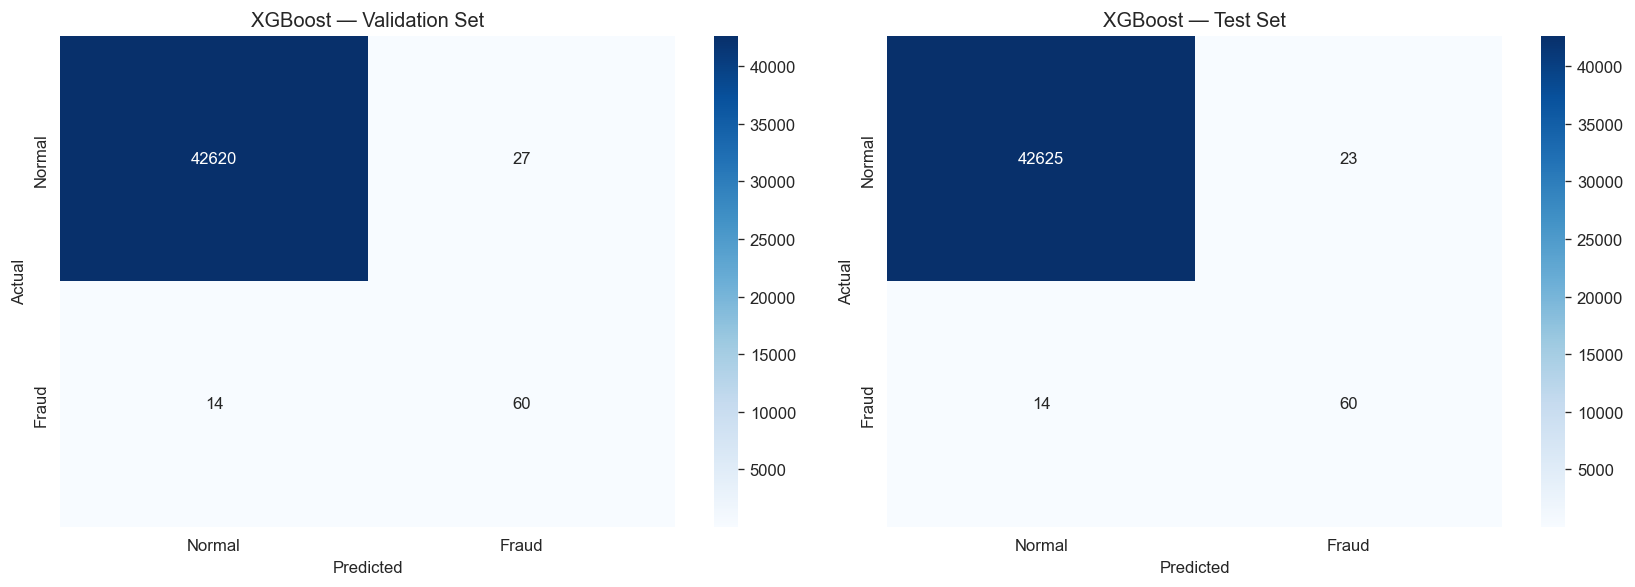

In [7]:
for name, model in models.items():
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    plot_confusion_matrices(y_val, y_val_pred, y_test, y_test_pred, name, save=True)

---
## 4. Classification Report (Precision, Recall, F1 — Fraud Odaklı)

Her model için validation ve test seti raporları. Accuracy dahil.

In [8]:
for name, model in models.items():
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    print_classification_report_custom(y_val, y_val_pred, "Validation", name)
    print_classification_report_custom(y_test, y_test_pred, "Test", name)


  Logistic Regression — Validation
  Accuracy: 0.976148
              precision    recall  f1-score   support

      Normal   0.999760  0.976341  0.987912     42647
       Fraud   0.059646  0.864865  0.111595        74

    accuracy                       0.976148     42721
   macro avg   0.529703  0.920603  0.549753     42721
weighted avg   0.998131  0.976148  0.986394     42721


  Logistic Regression — Test
  Accuracy: 0.976172
              precision    recall  f1-score   support

      Normal   0.999760  0.976365  0.987924     42648
       Fraud   0.059701  0.864865  0.111693        74

    accuracy                       0.976172     42722
   macro avg   0.529731  0.920615  0.549808     42722
weighted avg   0.998132  0.976172  0.986406     42722


  Random Forest — Validation
  Accuracy: 0.999345
              precision    recall  f1-score   support

      Normal   0.999555  0.999789  0.999672     42647
       Fraud   0.859375  0.743243  0.797101        74

    accuracy           

---
## 5. ROC-AUC & PR Curves — Hesaplama

Test seti üzerinde ROC ve Precision-Recall metrikleri hesaplanır.

In [9]:
all_results = {}

for name, model in models.items():
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    res = compute_roc_pr(y_test, y_test_proba)

    report = classification_report(y_test, y_test_pred, output_dict=True)
    res['accuracy'] = accuracy_score(y_test, y_test_pred)
    res['precision_fraud'] = report['1']['precision']
    res['recall_fraud'] = report['1']['recall']
    res['f1_fraud'] = report['1']['f1-score']

    # Threshold optimization
    best_t, best_f1, thresholds, f1_scores = find_best_threshold(y_test, y_test_proba)
    res['best_threshold'] = best_t
    res['best_f1'] = best_f1

    all_results[name] = res

    print(f"{name}: ROC-AUC={res['roc_auc']:.4f}  PR-AUC={res['pr_auc']:.4f}  "
          f"Best Threshold={best_t:.2f}  F1@best={best_f1:.4f}")

Logistic Regression: ROC-AUC=0.9767  PR-AUC=0.7902  Best Threshold=0.99  F1@best=0.7006
Random Forest: ROC-AUC=0.9754  PR-AUC=0.8449  Best Threshold=0.51  F1@best=0.8551
XGBoost: ROC-AUC=0.9681  PR-AUC=0.8280  Best Threshold=0.94  F1@best=0.8507


### 5.1 ROC-AUC — 3 Model Aynı Grafikte

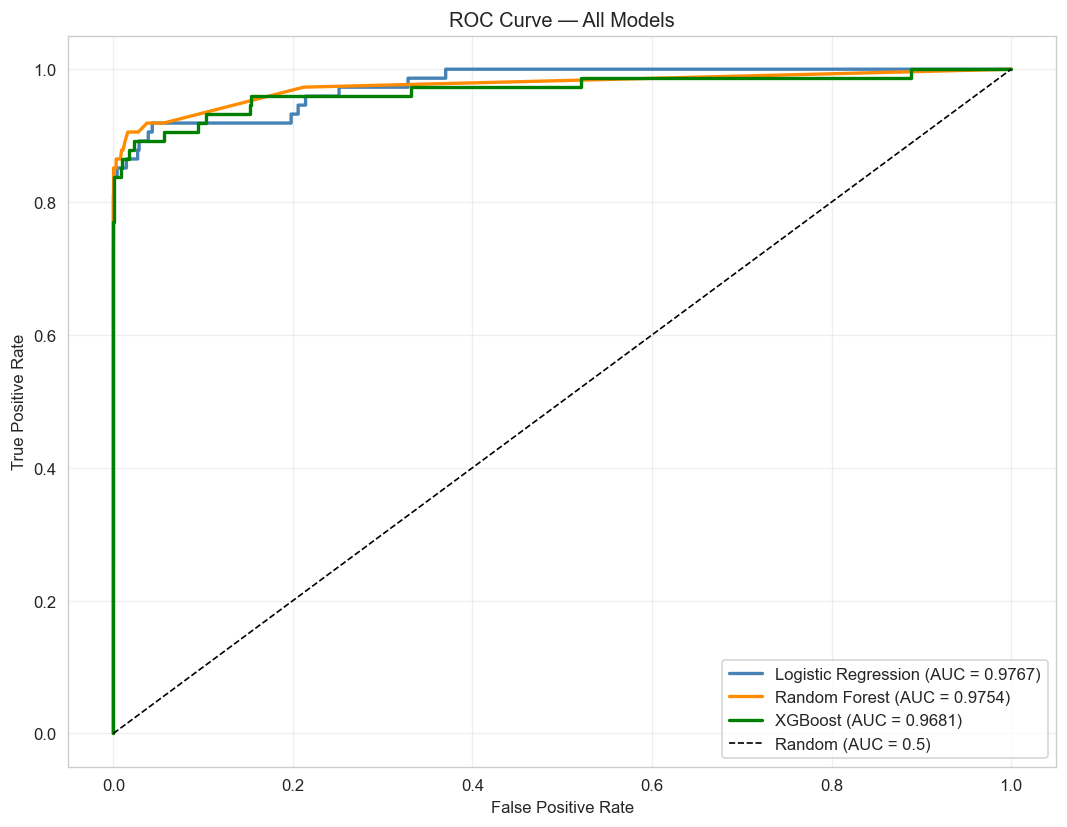

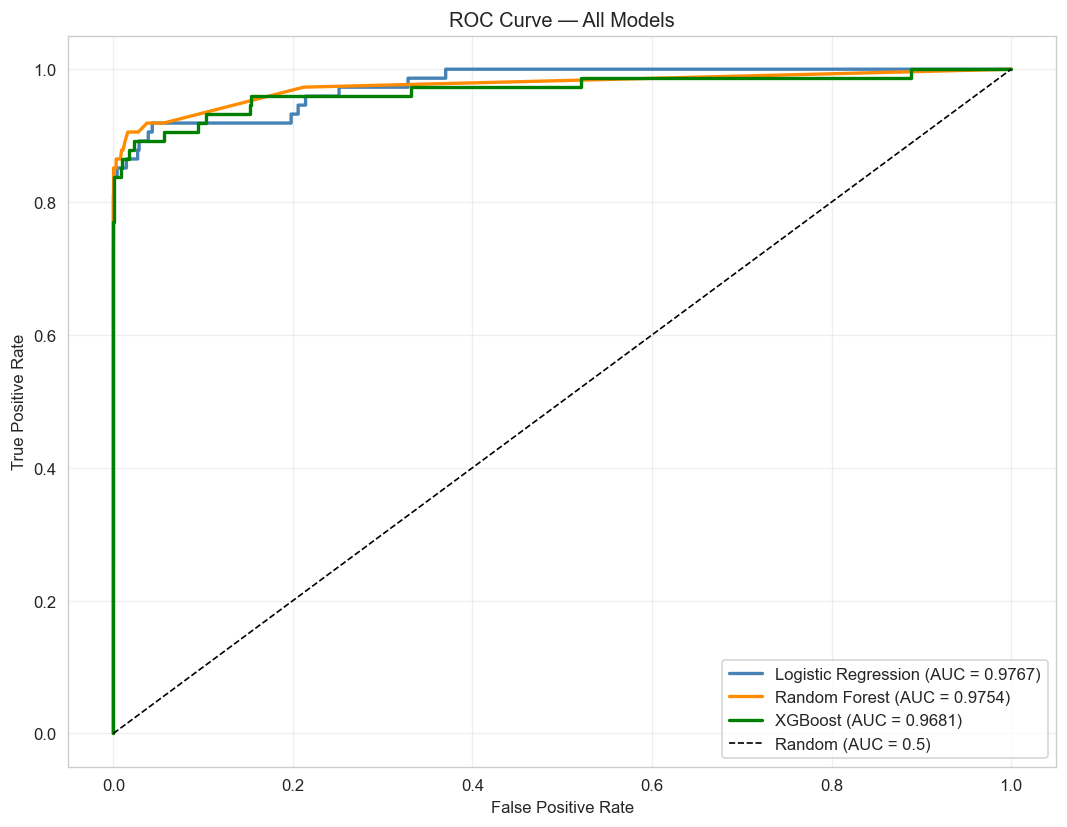

In [10]:
plot_roc_combined(all_results, save=True)

### 5.2 ROC-AUC — Modeller Ayrı Ayrı

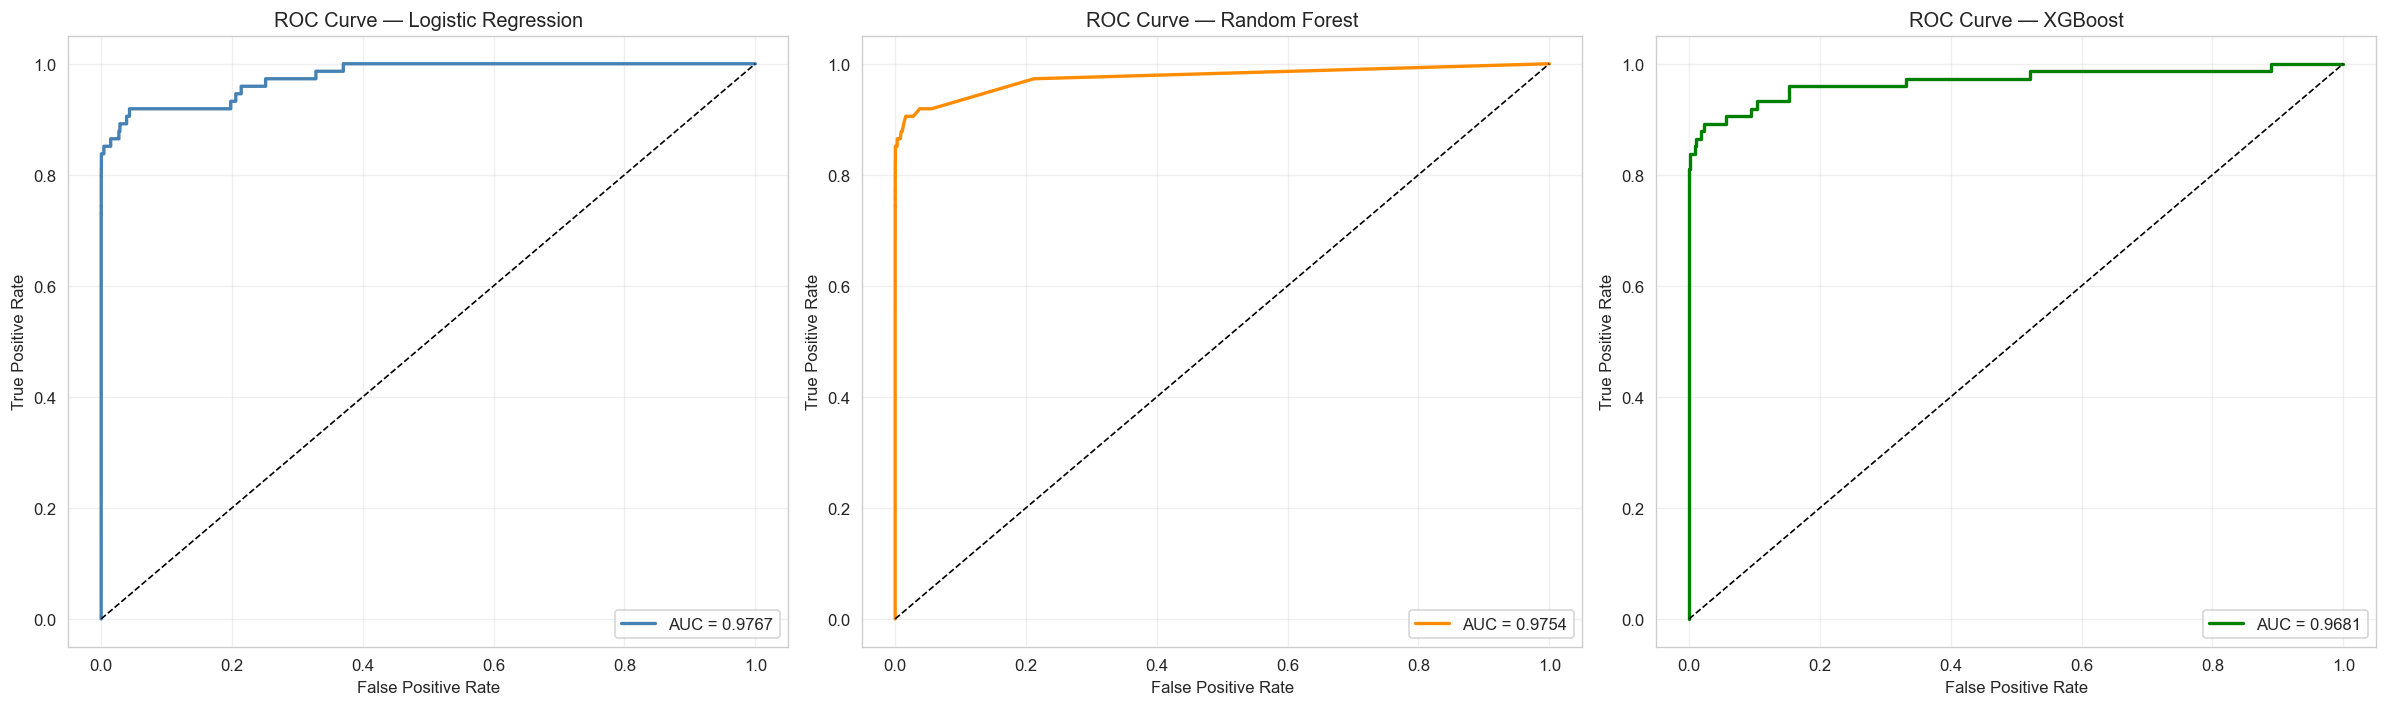

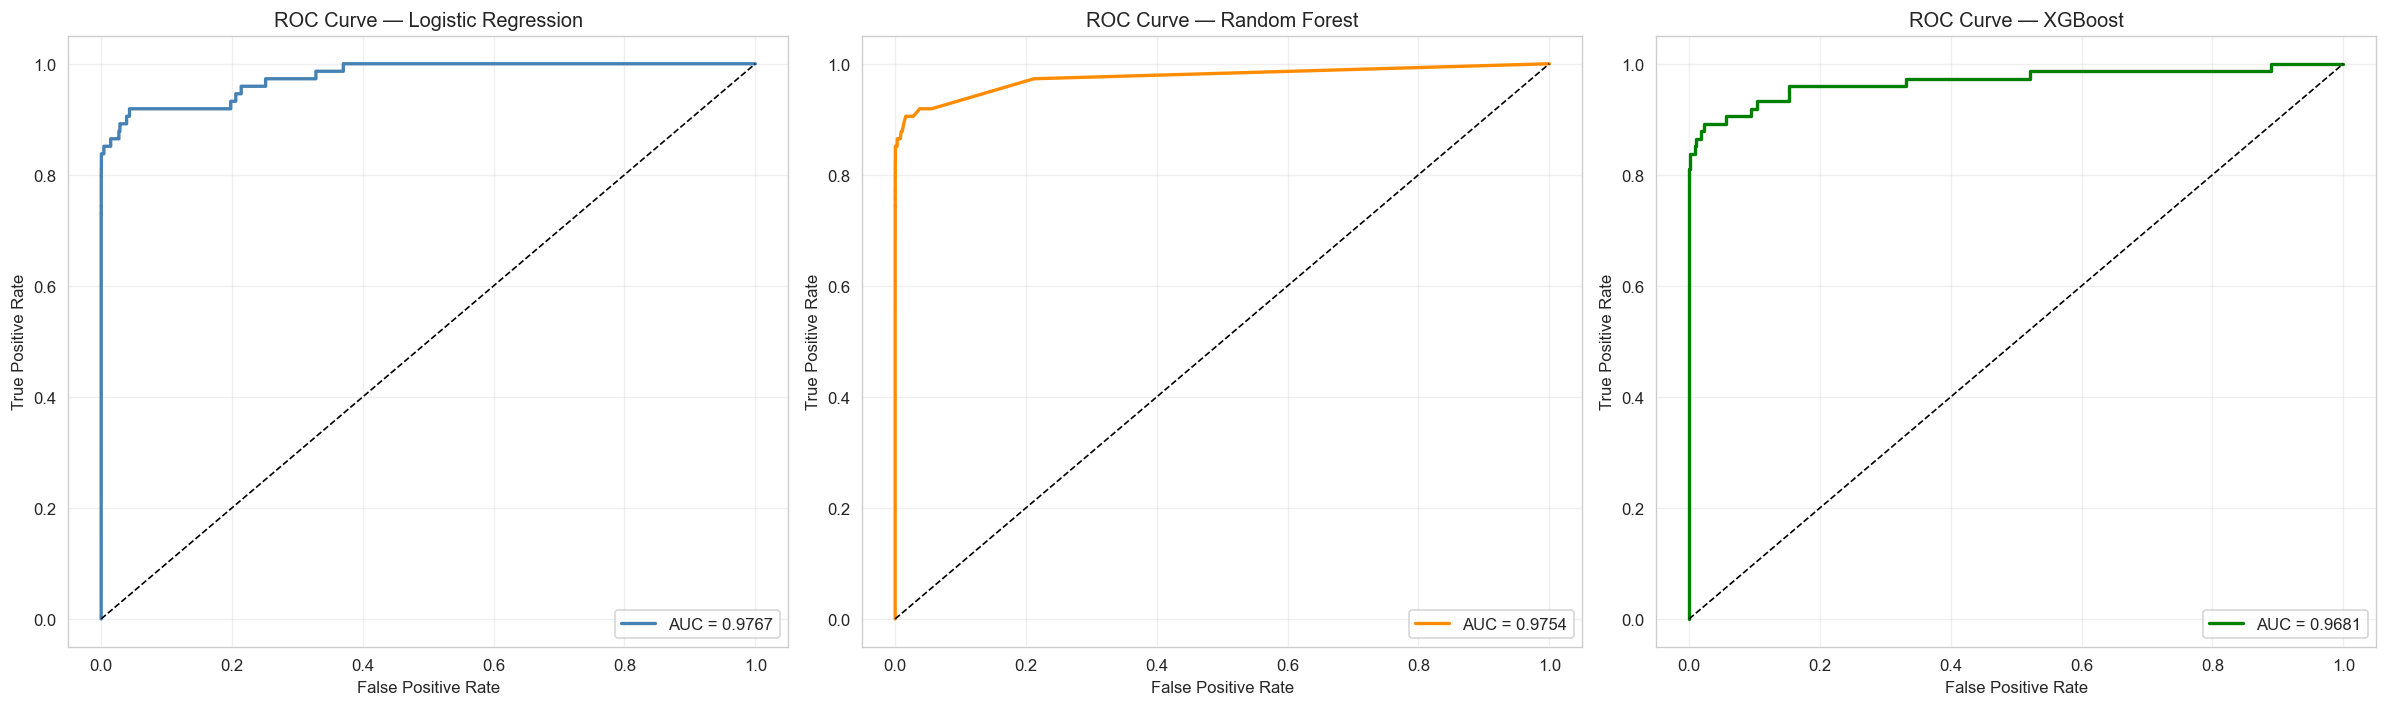

In [11]:
plot_roc_individual(all_results, save=True)

### 5.3 Precision-Recall — 3 Model Aynı Grafikte

Imbalanced data için ROC'tan daha bilgilendirici. PR-AUC (Average Precision) her model için annotated.

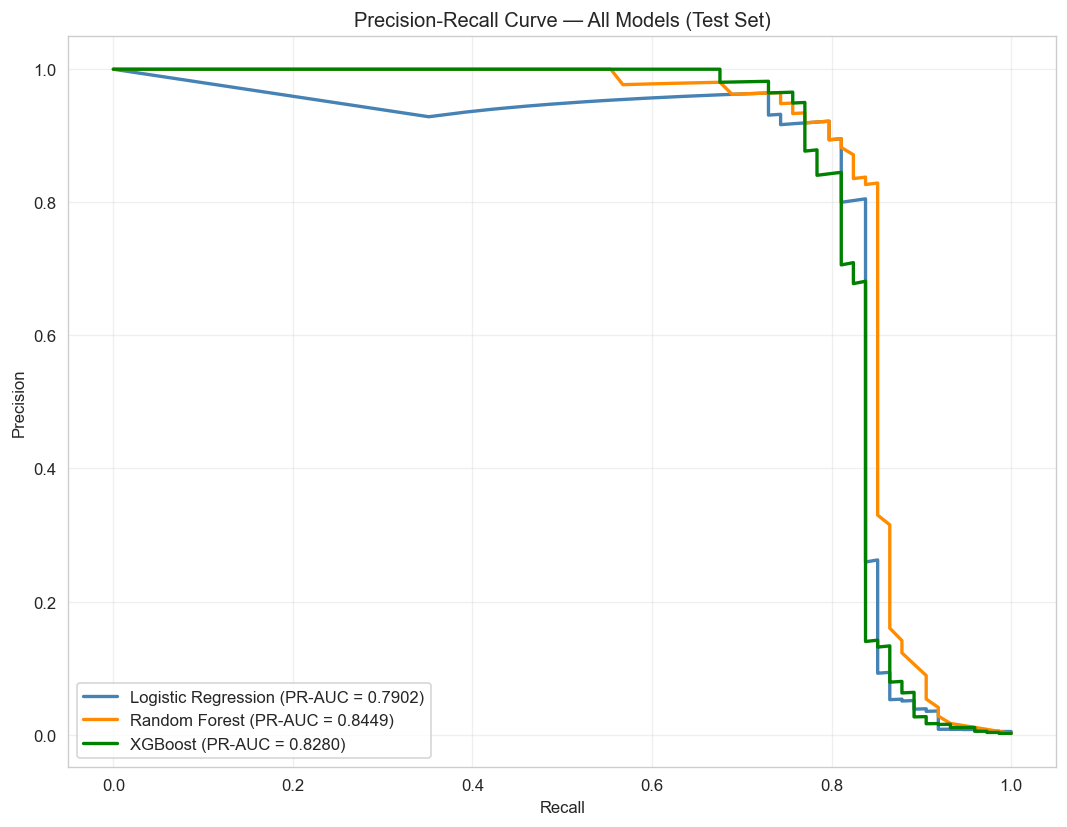

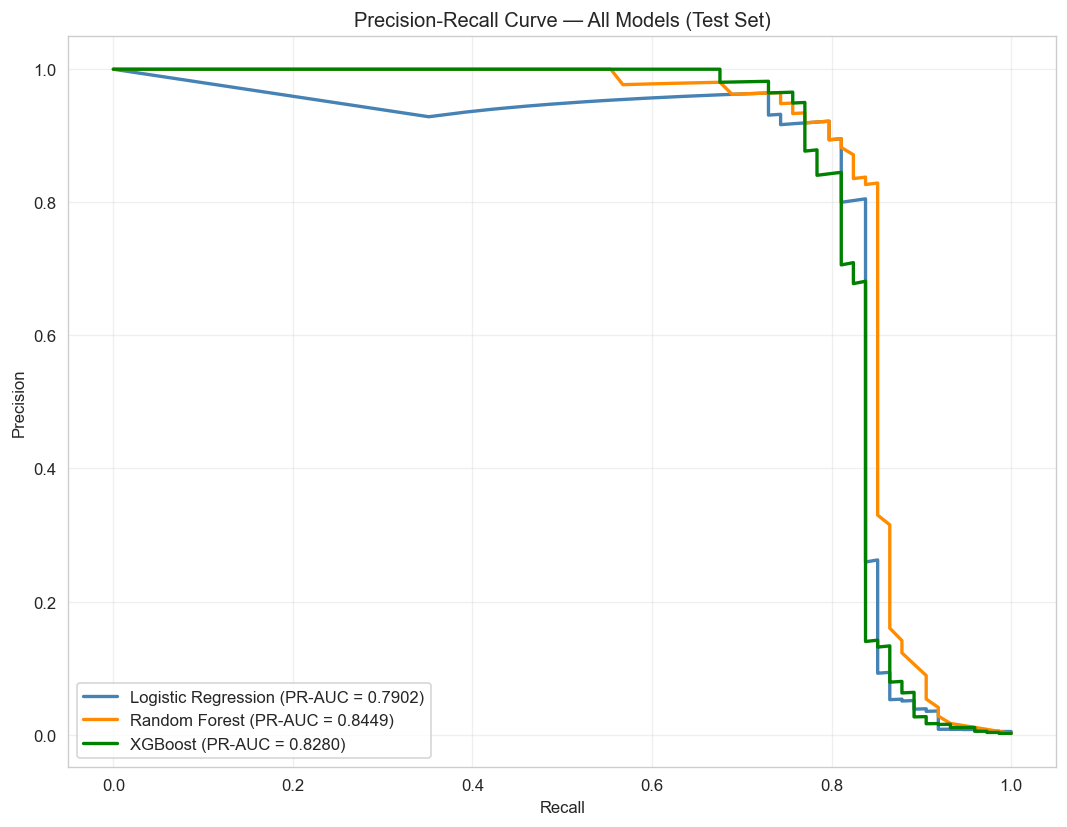

In [12]:
plot_pr_combined(all_results, save=True)

### 5.4 Precision-Recall — Modeller Ayrı Ayrı

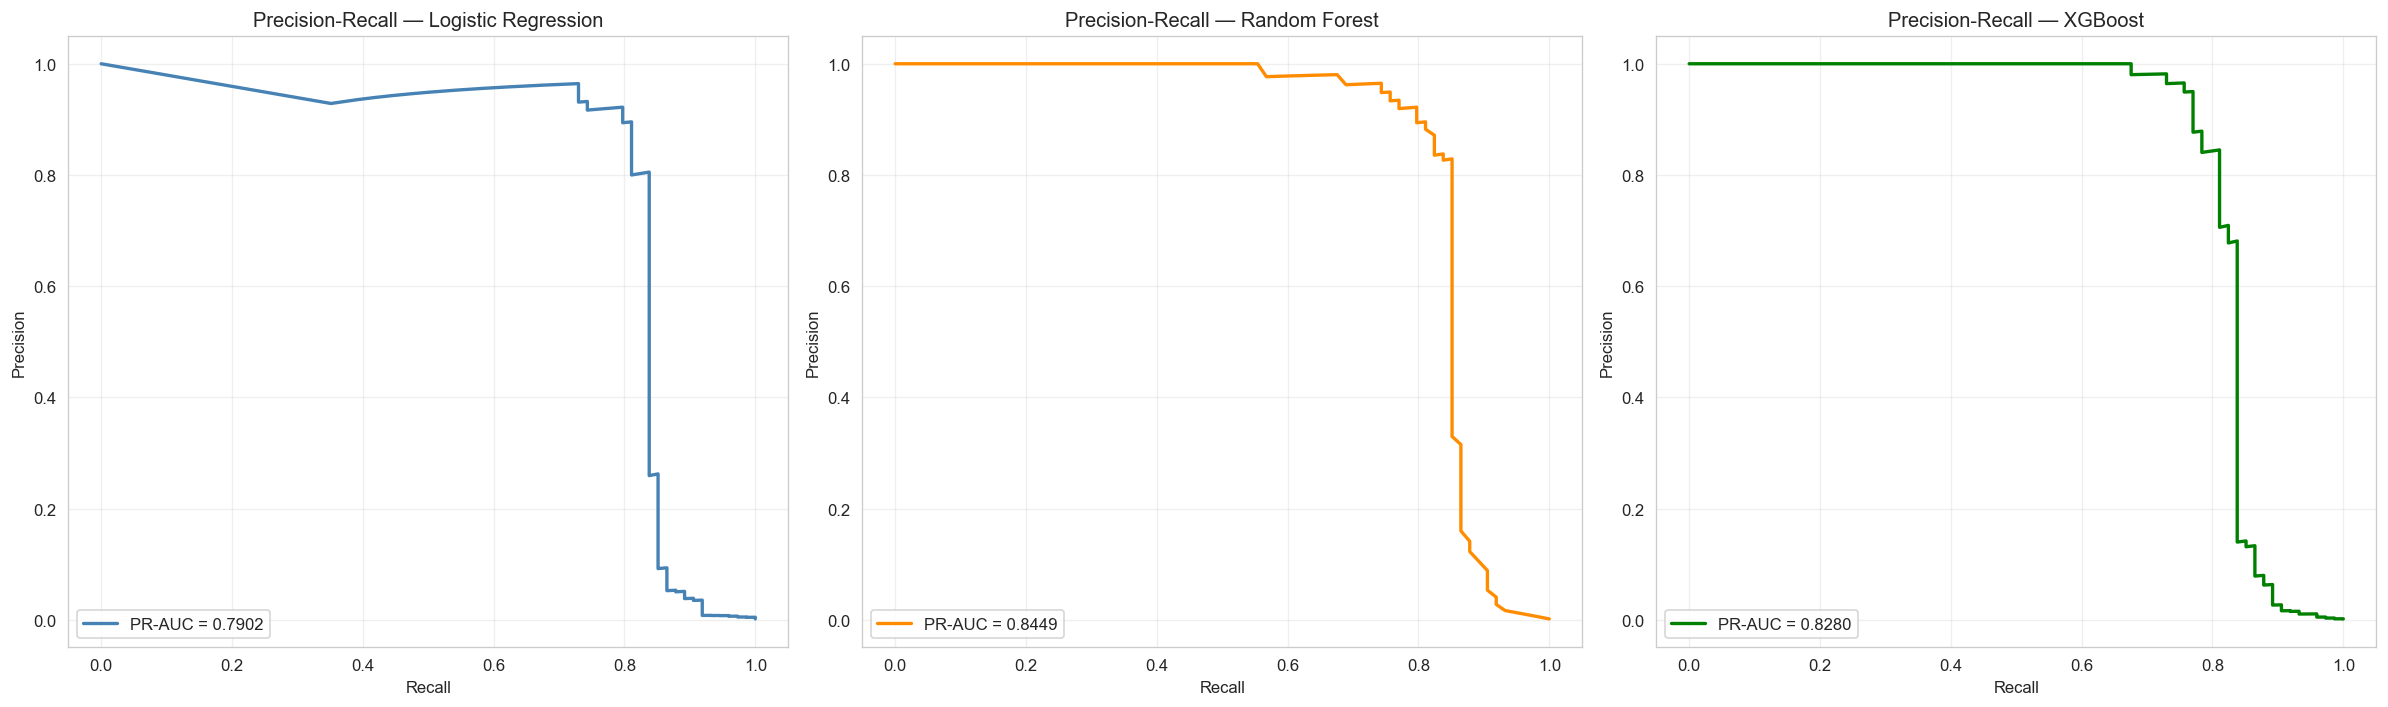

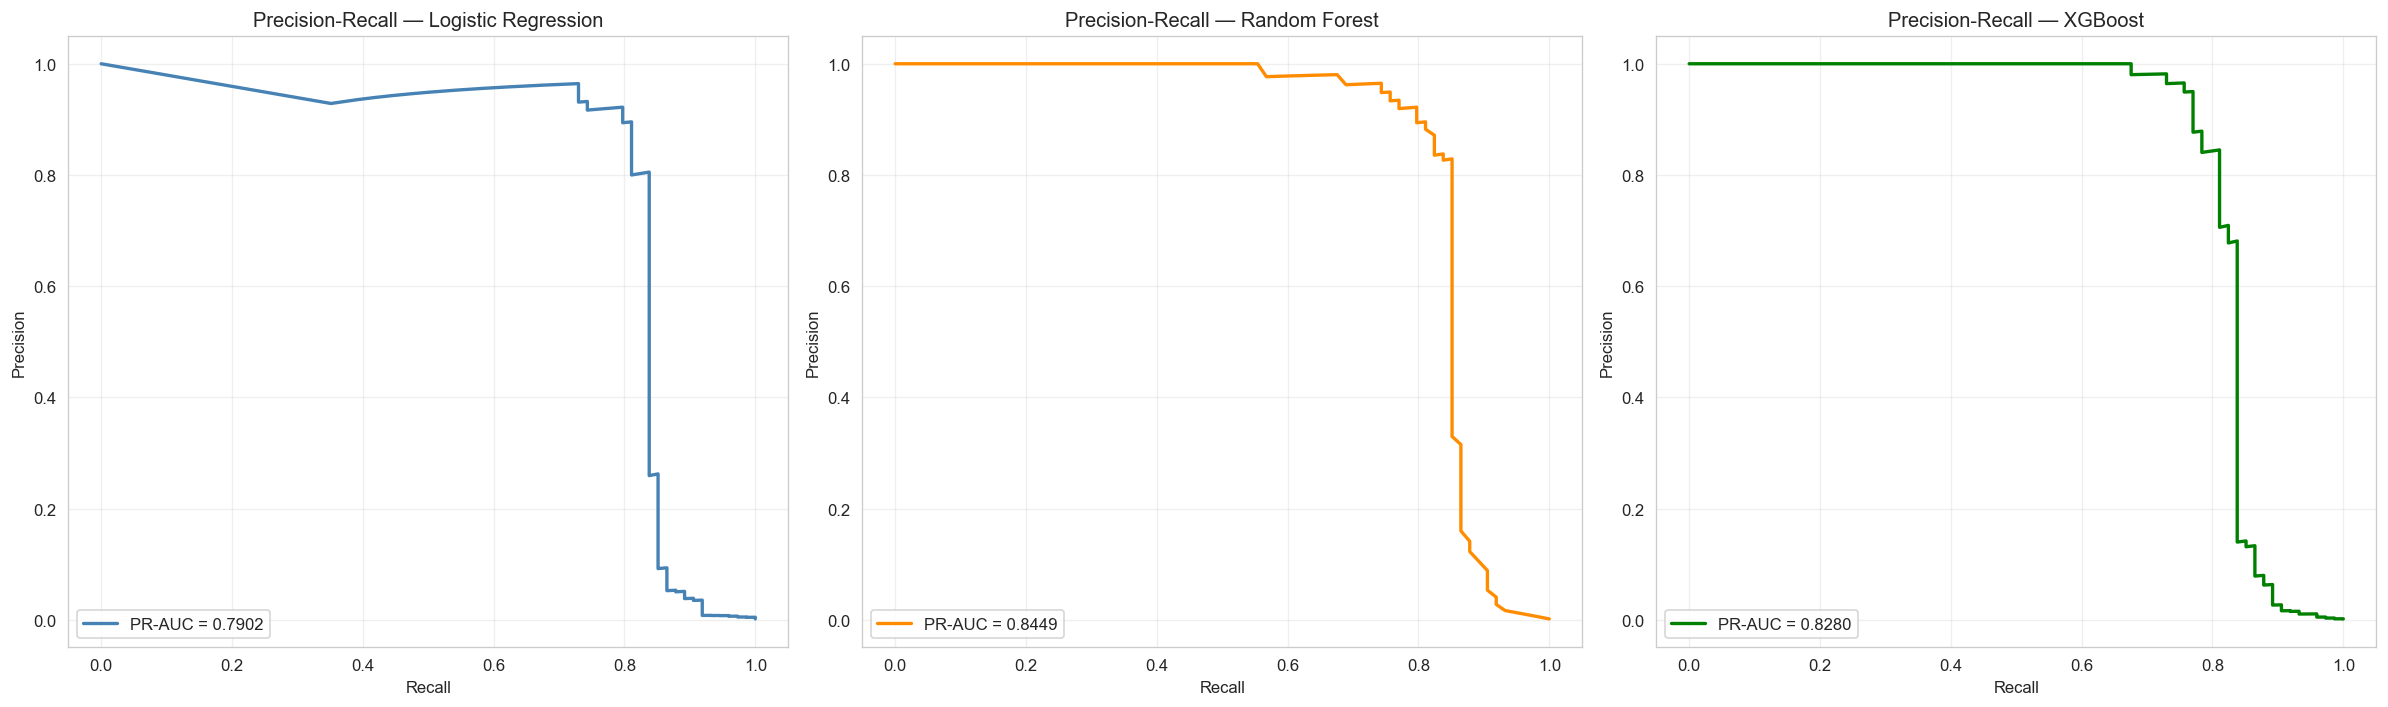

In [13]:
plot_pr_individual(all_results, save=True)

---
## 6. Threshold Optimization

Default 0.5 yerine, F1-score'u maksimize eden threshold bulunur.


  Logistic Regression
  Default threshold (0.50): F1 = 0.1117
  Optimal threshold (0.99): F1 = 0.7006


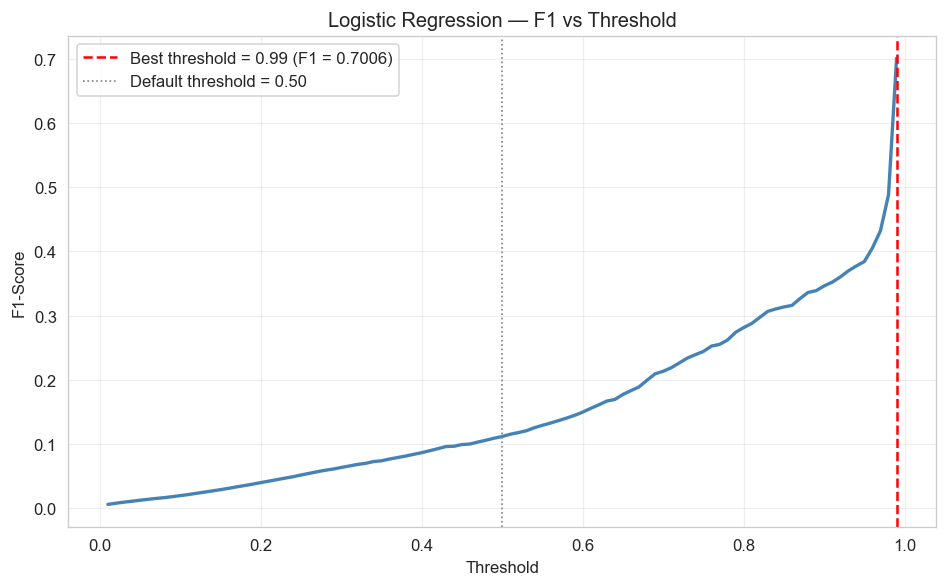


  Random Forest
  Default threshold (0.50): F1 = 0.8489
  Optimal threshold (0.51): F1 = 0.8551


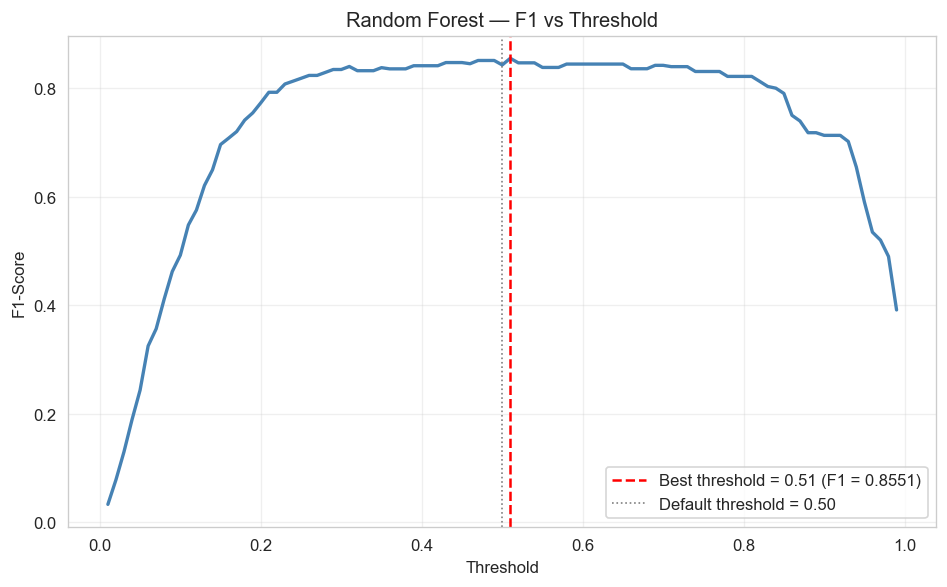


  XGBoost
  Default threshold (0.50): F1 = 0.7643
  Optimal threshold (0.94): F1 = 0.8507


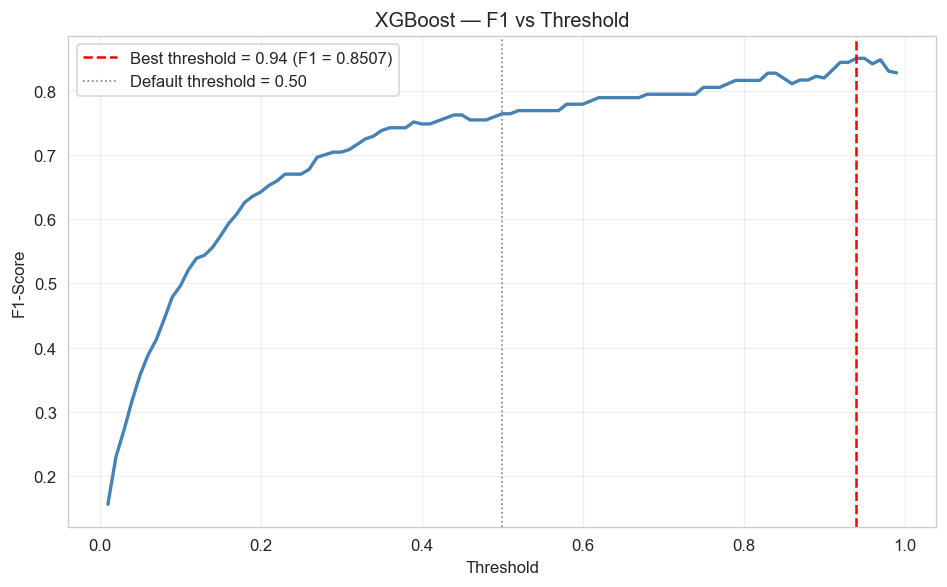

In [14]:
for name, model in models.items():
    y_test_proba = model.predict_proba(X_test)[:, 1]
    best_t = all_results[name]['best_threshold']
    best_f1 = all_results[name]['best_f1']
    _, _, thresholds, f1_scores = find_best_threshold(y_test, y_test_proba)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Default threshold (0.50): F1 = {f1_score(y_test, model.predict(X_test)):.4f}")
    print(f"  Optimal threshold ({best_t:.2f}): F1 = {best_f1:.4f}")
    print(f"{'='*50}")

    plot_f1_vs_threshold(thresholds, f1_scores, best_t, best_f1, name, save=True)

### 6.1 Optimal Threshold ile Classification Report & Confusion Matrix


  Logistic Regression — Test @threshold=0.99
  Accuracy: 0.998759
              precision    recall  f1-score   support

      Normal   0.999718  0.999039  0.999378     42648
       Fraud   0.601942  0.837838  0.700565        74

    accuracy                       0.998759     42722
   macro avg   0.800830  0.918438  0.849972     42722
weighted avg   0.999029  0.998759  0.998861     42722



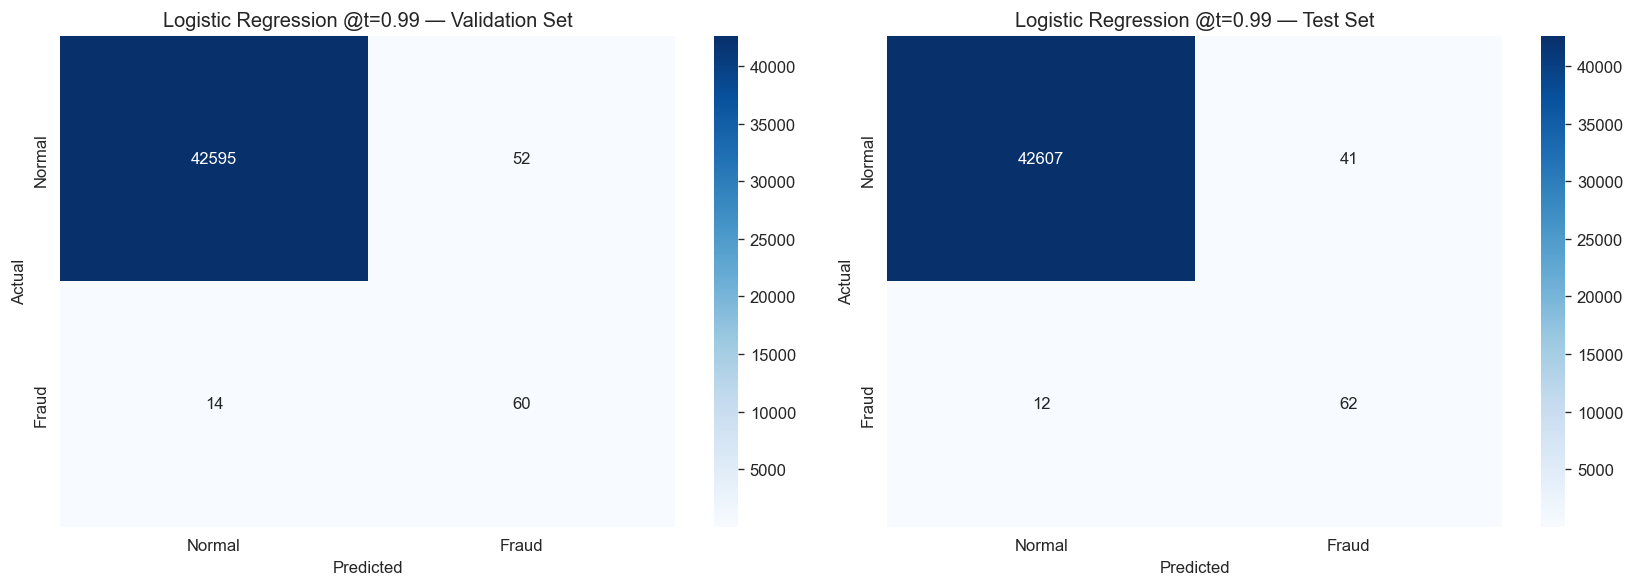


  Random Forest — Test @threshold=0.51
  Accuracy: 0.999532
              precision    recall  f1-score   support

      Normal   0.999648  0.999883  0.999766     42648
       Fraud   0.921875  0.797297  0.855072        74

    accuracy                       0.999532     42722
   macro avg   0.960762  0.898590  0.927419     42722
weighted avg   0.999514  0.999532  0.999515     42722



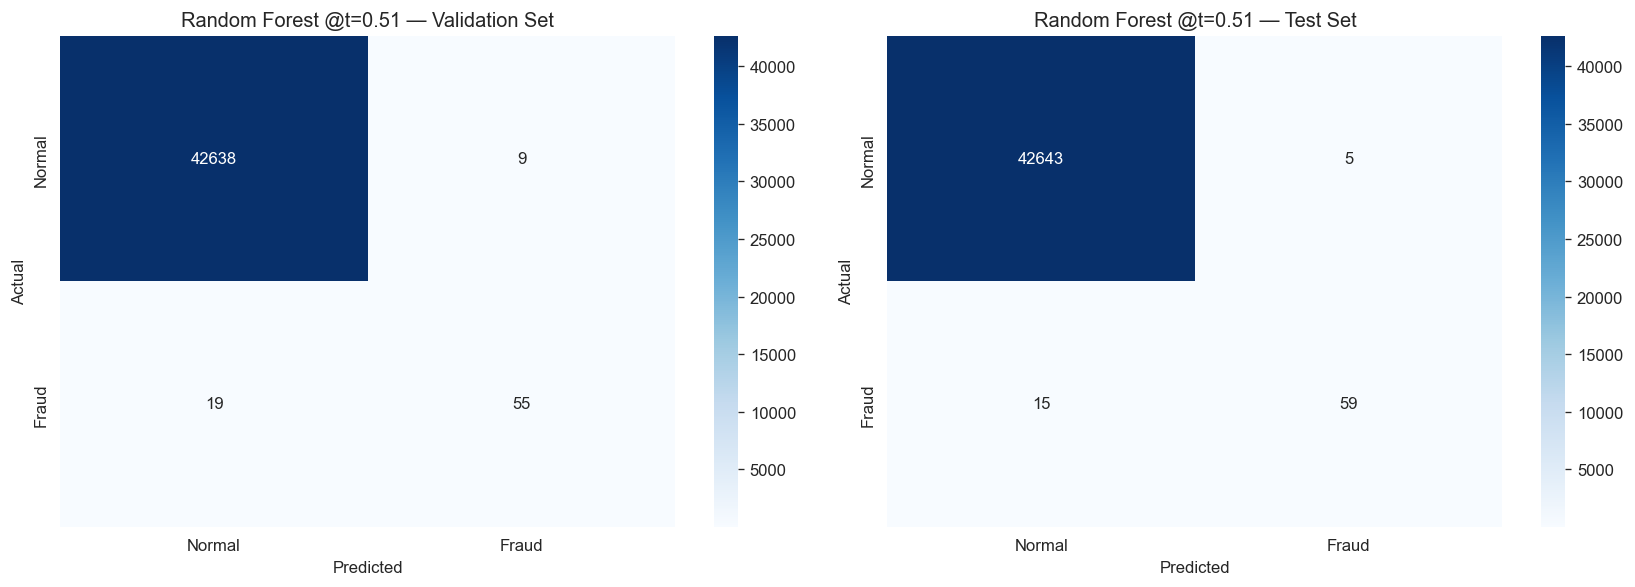


  XGBoost — Test @threshold=0.94
  Accuracy: 0.999532
              precision    recall  f1-score   support

      Normal   0.999602  0.999930  0.999766     42648
       Fraud   0.950000  0.770270  0.850746        74

    accuracy                       0.999532     42722
   macro avg   0.974801  0.885100  0.925256     42722
weighted avg   0.999516  0.999532  0.999507     42722



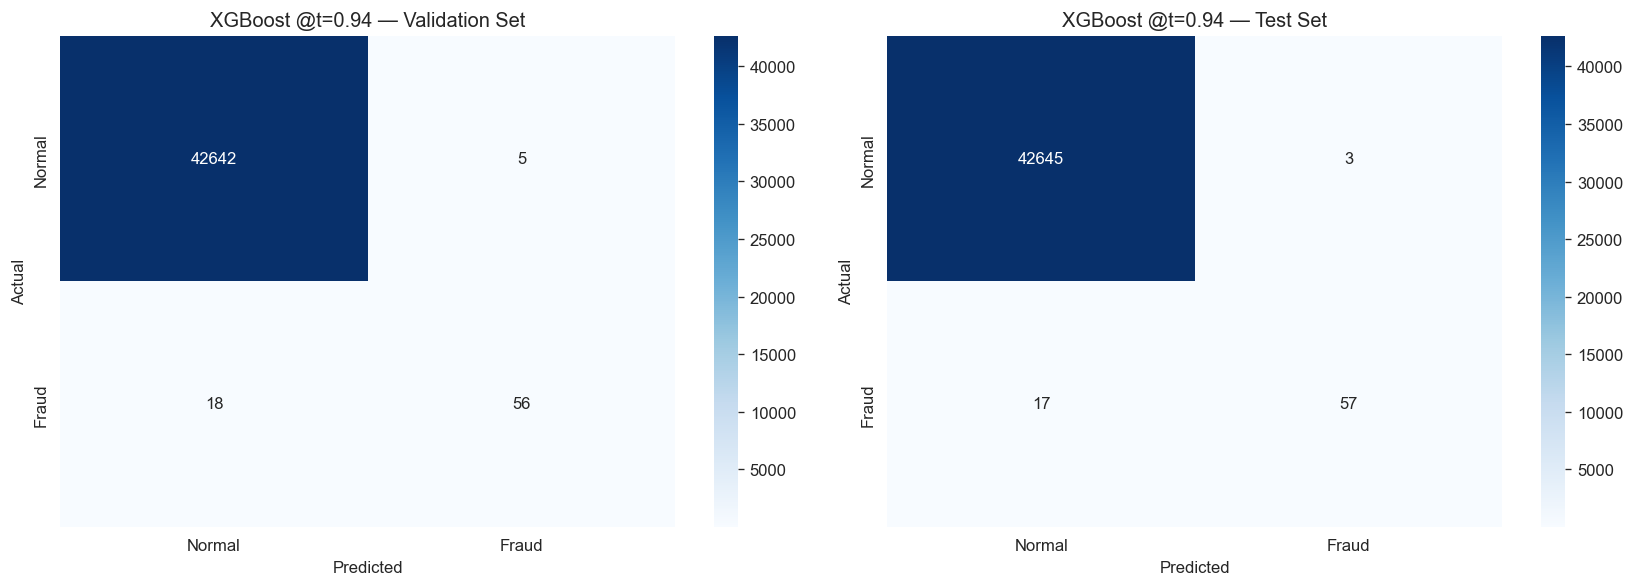

In [15]:
for name, model in models.items():
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]
    best_t = all_results[name]['best_threshold']

    y_test_pred_opt = (y_test_proba >= best_t).astype(int)
    y_val_pred_opt = (y_val_proba >= best_t).astype(int)

    print_classification_report_custom(y_test, y_test_pred_opt,
                                       f"Test @threshold={best_t:.2f}", name)
    plot_confusion_matrices(y_val, y_val_pred_opt, y_test, y_test_pred_opt,
                            f"{name} @t={best_t:.2f}", save=True)

---
## 7. Model Comparison Summary

In [16]:
summary_df = build_summary_table(all_results)
print(summary_df.to_string(index=False))
summary_df

              Model  ROC-AUC   PR-AUC  Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  Best Threshold  F1 at Best Threshold
Logistic Regression 0.976650 0.790196  0.976172           0.059701        0.864865    0.111693            0.99              0.700565
      Random Forest 0.975399 0.844904  0.999508           0.907692        0.797297    0.848921            0.51              0.855072
            XGBoost 0.968077 0.828006  0.999134           0.722892        0.810811    0.764331            0.94              0.850746


,Model,ROC-AUC,PR-AUC,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),Best Threshold,F1 at Best Threshold
0,Logistic Regression,0.976650,0.790196,0.976172,0.059701,0.864865,0.111693,0.99,0.700565
1,Random Forest,0.975399,0.844904,0.999508,0.907692,0.797297,0.848921,0.51,0.855072
2,XGBoost,0.968077,0.828006,0.999134,0.722892,0.810811,0.764331,0.94,0.850746


In [17]:
# En iyi model PR-AUC'ye göre seçilir
best_model_name = max(all_results, key=lambda k: all_results[k]['pr_auc'])
print(f"\nEn iyi model (PR-AUC): {best_model_name}")
print(f"  ROC-AUC = {all_results[best_model_name]['roc_auc']:.4f}")
print(f"  PR-AUC  = {all_results[best_model_name]['pr_auc']:.4f}")


En iyi model (PR-AUC): Random Forest
  ROC-AUC = 0.9754
  PR-AUC  = 0.8449


---
## 8. Optuna Bayesian Hyperparameter Optimization

PR-AUC'si en yüksek model Optuna ile optimize edilir (30 trial, validation set üzerinde, 30 dk timeout).

In [18]:
import time as _time
_t0 = _time.time()
study = run_optuna_optimization(best_model_name, X_train, y_train,
                                X_val, y_val, n_trials=30)
print(f"\nOptimization completed in {_time.time() - _t0:.1f}s")

Best trial: 12. Best value: 0.826553:  70%|███████   | 21/30 [31:02<13:18, 88.67s/it, 1862.03/1800 seconds] 


  Optuna Optimization — Random Forest
  Best PR-AUC: 0.826553
  Best Parameters:
    n_estimators: 160
    max_depth: 28
    min_samples_split: 5
    min_samples_leaf: 1
    max_features: sqrt

Optimization completed in 1862.1s


In [19]:
print(f"\n{'='*60}")
print(f"  Optimızed {best_model_name} — En İyi Hiperparametreler")
print(f"{'='*60}")
print(f"  Best PR-AUC (val): {study.best_value:.6f}")
print(f"  Number of trials: {len(study.trials)}")
print(f"\n  Parametreler:")
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f"    {k:25s}: {v:.8f}")
    else:
        print(f"    {k:25s}: {v}")


  Optimızed Random Forest — En İyi Hiperparametreler
  Best PR-AUC (val): 0.826553
  Number of trials: 21

  Parametreler:
    n_estimators             : 160
    max_depth                : 28
    min_samples_split        : 5
    min_samples_leaf         : 1
    max_features             : sqrt


### 8.1 Optuna Optimization Visualizations

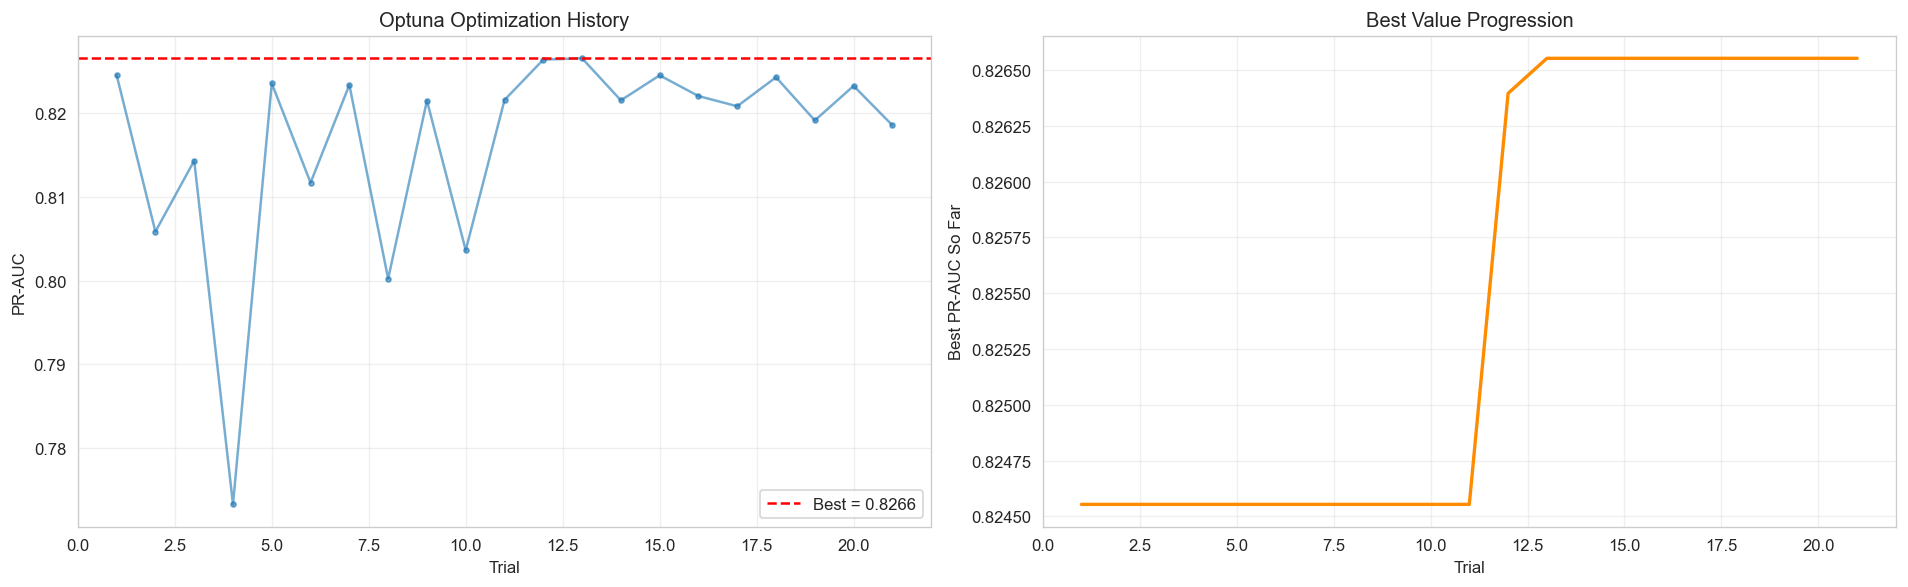

In [20]:
# Optimization history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trial values
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(range(1, len(trial_values)+1), trial_values, 'o-', ms=3, alpha=0.6)
axes[0].axhline(study.best_value, color='red', ls='--', lw=1.5,
                label=f'Best = {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Best value progression
best_so_far = np.maximum.accumulate(trial_values)
axes[1].plot(range(1, len(best_so_far)+1), best_so_far, '-', lw=2, color='darkorange')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Best PR-AUC So Far')
axes[1].set_title('Best Value Progression')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_history.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Optimized Model — Full Evaluation

In [21]:
# Train optimized model
optimized_model = train_optimized_model(best_model_name, study.best_params,
                                        X_train, y_train)

opt_name = f"{best_model_name} (Optimized)"
print(f"Optimized model trained: {opt_name}")

Optimized model trained: Random Forest (Optimized)


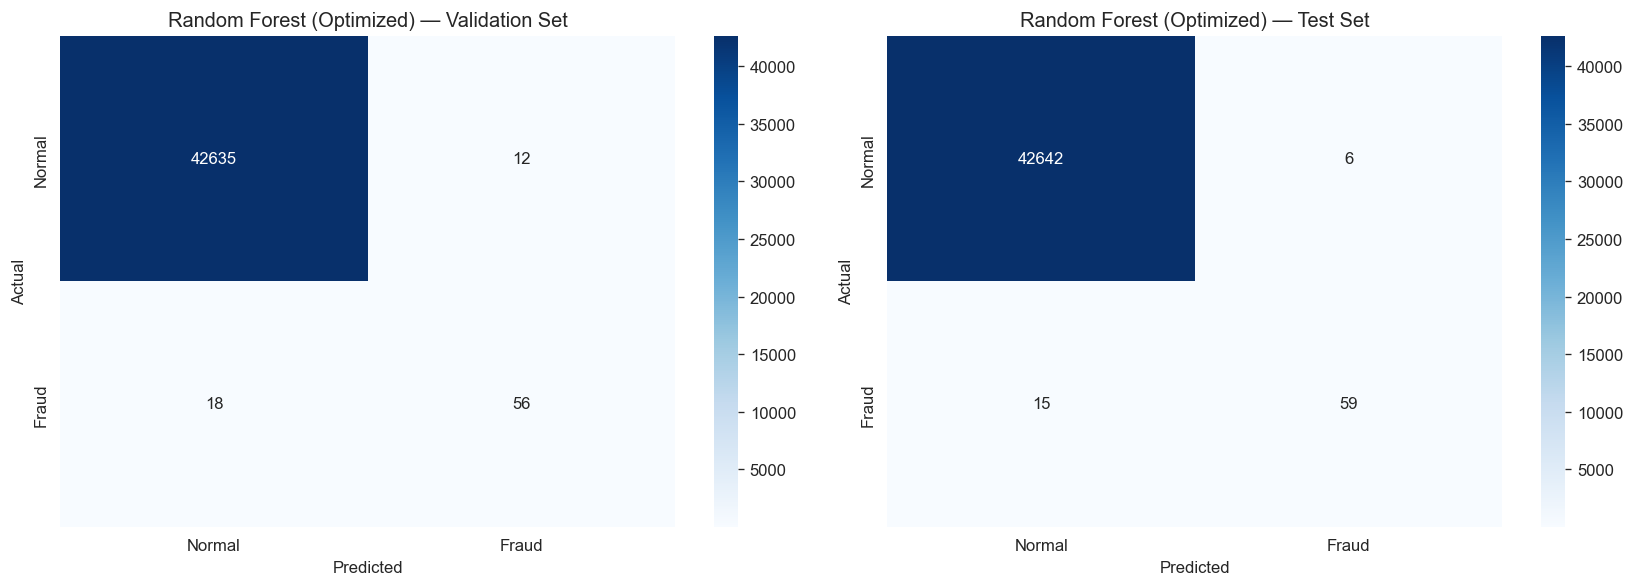

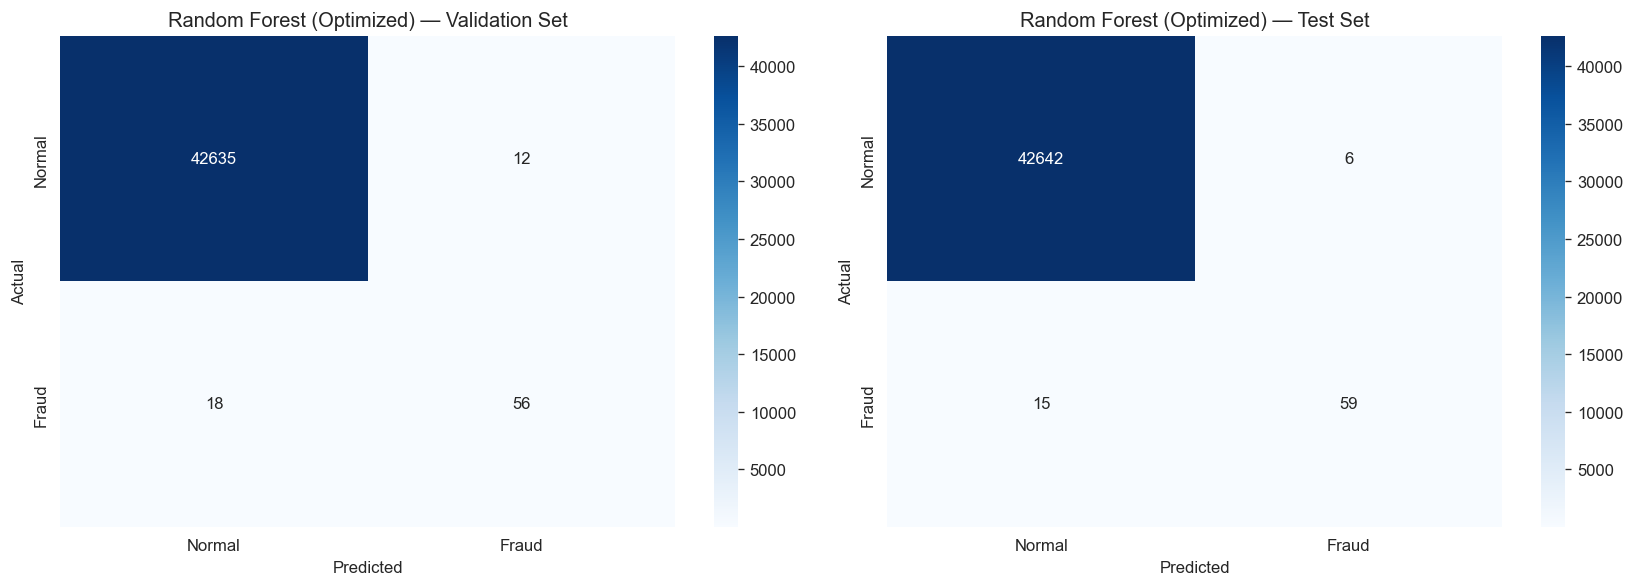

In [22]:
# Predictions
y_val_pred_opt = optimized_model.predict(X_val)
y_test_pred_opt = optimized_model.predict(X_test)
y_val_proba_opt = optimized_model.predict_proba(X_val)[:, 1]
y_test_proba_opt = optimized_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
plot_confusion_matrices(y_val, y_val_pred_opt, y_test, y_test_pred_opt, opt_name, save=True)

In [23]:
# Classification Reports
print_classification_report_custom(y_val, y_val_pred_opt, "Validation", opt_name)
print_classification_report_custom(y_test, y_test_pred_opt, "Test", opt_name)


  Random Forest (Optimized) — Validation
  Accuracy: 0.999298
              precision    recall  f1-score   support

      Normal   0.999578  0.999719  0.999648     42647
       Fraud   0.823529  0.756757  0.788732        74

    accuracy                       0.999298     42721
   macro avg   0.911554  0.878238  0.894190     42721
weighted avg   0.999273  0.999298  0.999283     42721


  Random Forest (Optimized) — Test
  Accuracy: 0.999508
              precision    recall  f1-score   support

      Normal   0.999648  0.999859  0.999754     42648
       Fraud   0.907692  0.797297  0.848921        74

    accuracy                       0.999508     42722
   macro avg   0.953670  0.898578  0.924337     42722
weighted avg   0.999489  0.999508  0.999493     42722



In [24]:
# ROC & PR metrics
opt_res = compute_roc_pr(y_test, y_test_proba_opt)
report_opt = classification_report(y_test, y_test_pred_opt, output_dict=True)
opt_res['accuracy'] = accuracy_score(y_test, y_test_pred_opt)
opt_res['precision_fraud'] = report_opt['1']['precision']
opt_res['recall_fraud'] = report_opt['1']['recall']
opt_res['f1_fraud'] = report_opt['1']['f1-score']

# Threshold optimization for optimized model
best_t_opt, best_f1_opt, thresholds_opt, f1_scores_opt = find_best_threshold(
    y_test, y_test_proba_opt)
opt_res['best_threshold'] = best_t_opt
opt_res['best_f1'] = best_f1_opt

print(f"\n{opt_name}:")
print(f"  ROC-AUC:        {opt_res['roc_auc']:.4f}")
print(f"  PR-AUC:         {opt_res['pr_auc']:.4f}")
print(f"  Best Threshold: {best_t_opt:.2f}")
print(f"  F1 @best:       {best_f1_opt:.4f}")

all_results[opt_name] = opt_res


Random Forest (Optimized):
  ROC-AUC:        0.9802
  PR-AUC:         0.8422
  Best Threshold: 0.46
  F1 @best:       0.8531


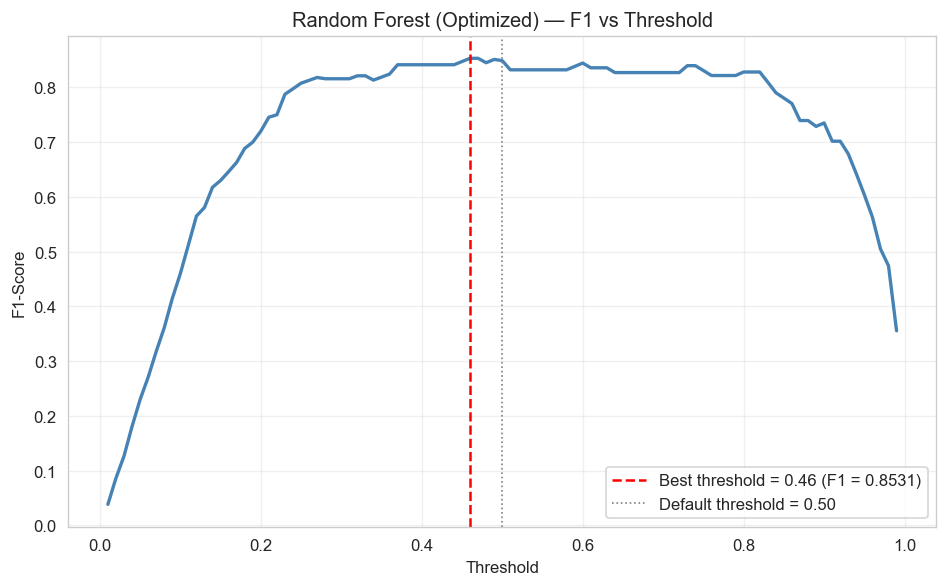

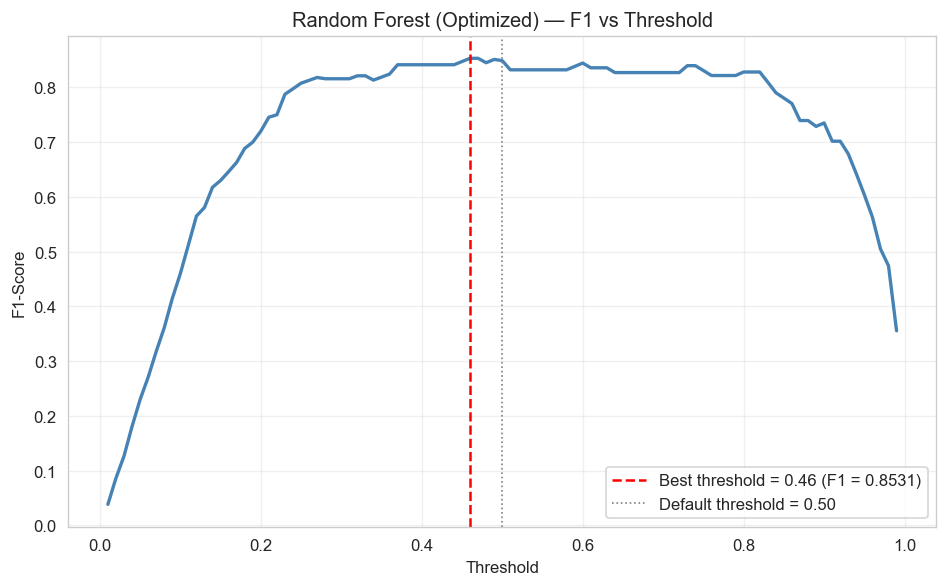

In [25]:
# F1 vs Threshold for optimized model
plot_f1_vs_threshold(thresholds_opt, f1_scores_opt, best_t_opt, best_f1_opt,
                     opt_name, save=True)

In [26]:
# Optimal threshold classification report
y_test_pred_opt_t = (y_test_proba_opt >= best_t_opt).astype(int)
print_classification_report_custom(y_test, y_test_pred_opt_t,
                                   f"Test @threshold={best_t_opt:.2f}", opt_name)


  Random Forest (Optimized) — Test @threshold=0.46
  Accuracy: 0.999508
              precision    recall  f1-score   support

      Normal   0.999695  0.999812  0.999754     42648
       Fraud   0.884058  0.824324  0.853147        74

    accuracy                       0.999508     42722
   macro avg   0.941877  0.912068  0.926450     42722
weighted avg   0.999495  0.999508  0.999500     42722



---
## 10. Final Comparison — All Models (Including Optimized)

### 10.1 ROC-AUC — Tüm Modeller

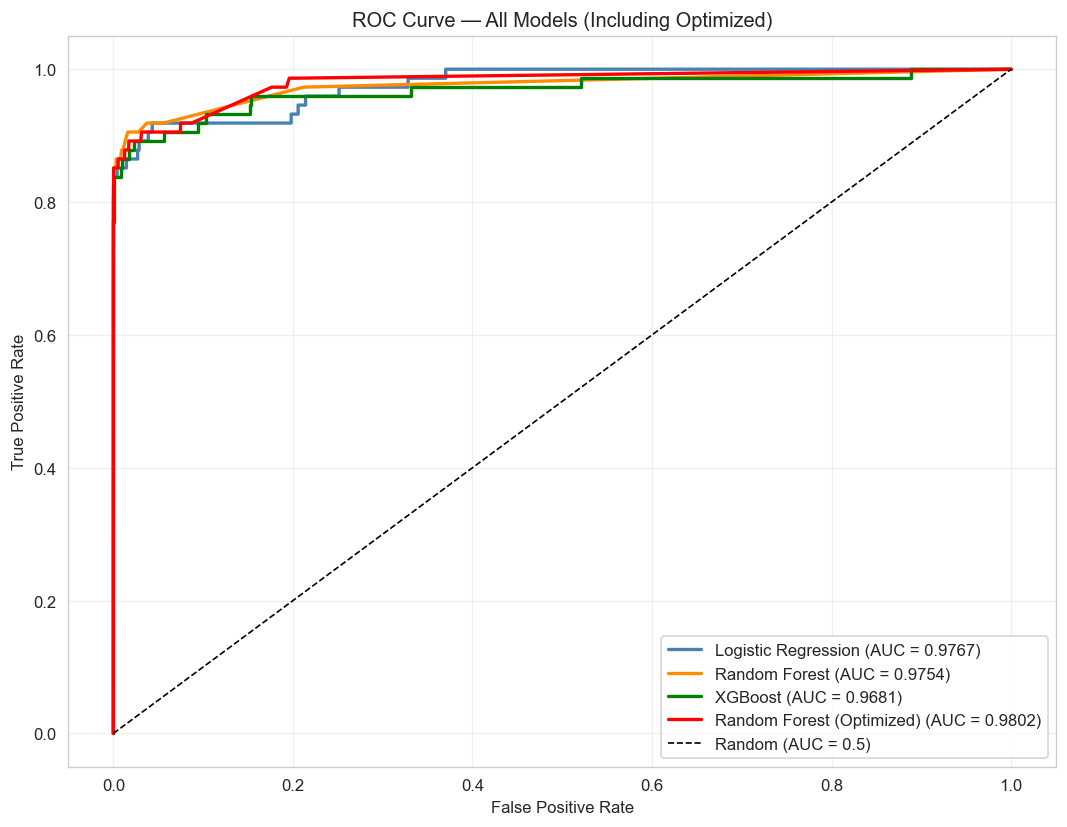

In [27]:
# Combined ROC with optimized model
colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest': 'darkorange',
    'XGBoost': 'green',
    opt_name: 'red',
}

fig, ax = plt.subplots(figsize=(9, 7))
for name, res in all_results.items():
    ax.plot(res['fpr'], res['tpr'], lw=2, color=colors.get(name, None),
            label=f"{name} (AUC = {res['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models (Including Optimized)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_final_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.2 Precision-Recall — Tüm Modeller

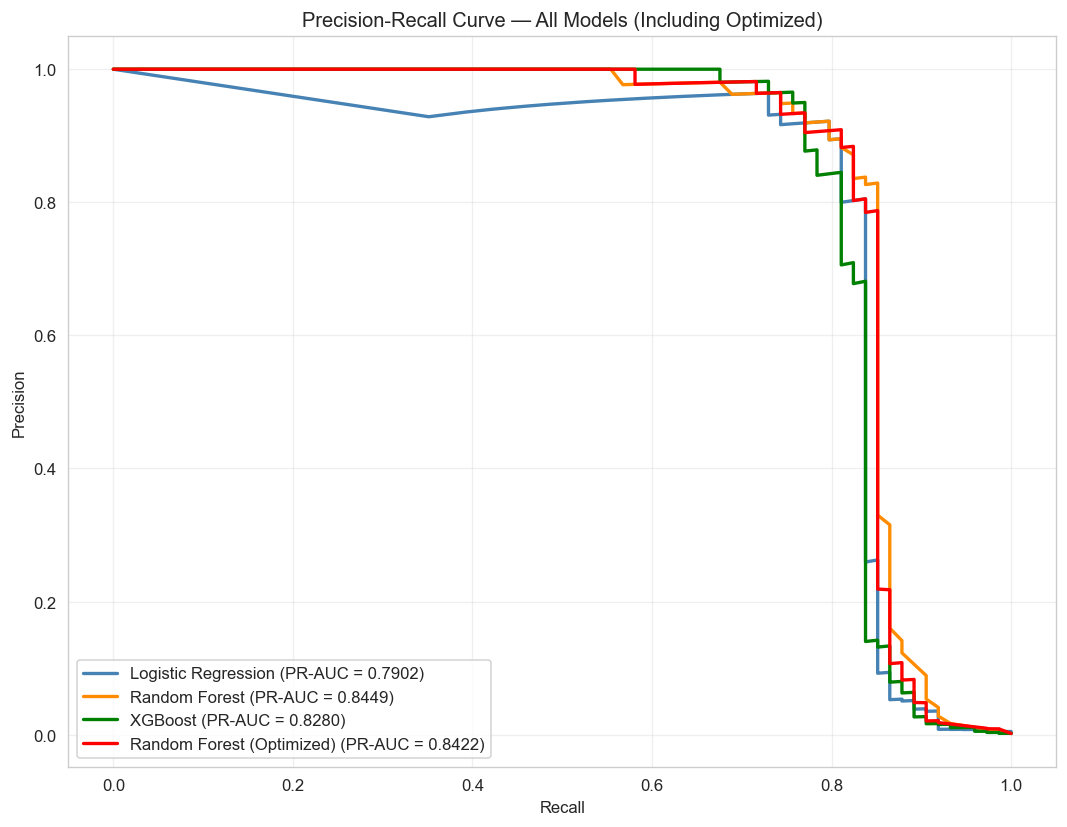

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))
for name, res in all_results.items():
    ax.plot(res['recall'], res['precision'], lw=2, color=colors.get(name, None),
            label=f"{name} (PR-AUC = {res['pr_auc']:.4f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — All Models (Including Optimized)')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pr_final_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Final Summary Table

In [29]:
final_summary = build_summary_table(all_results)
final_summary.to_csv(os.path.join(OUTPUT_DIR, 'final_comparison.csv'), index=False)

print(final_summary.to_string(index=False))
print()
final_summary.style.highlight_max(subset=[
    'ROC-AUC', 'PR-AUC', 'Recall (Fraud)', 'F1 (Fraud)', 'F1 at Best Threshold'
], color='lightgreen')

                    Model  ROC-AUC   PR-AUC  Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  Best Threshold  F1 at Best Threshold
      Logistic Regression 0.976650 0.790196  0.976172           0.059701        0.864865    0.111693            0.99              0.700565
            Random Forest 0.975399 0.844904  0.999508           0.907692        0.797297    0.848921            0.51              0.855072
                  XGBoost 0.968077 0.828006  0.999134           0.722892        0.810811    0.764331            0.94              0.850746
Random Forest (Optimized) 0.980200 0.842161  0.999508           0.907692        0.797297    0.848921            0.46              0.853147



,Model,ROC-AUC,PR-AUC,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),Best Threshold,F1 at Best Threshold
0,Logistic Regression,0.976650,0.790196,0.976172,0.059701,0.864865,0.111693,0.990000,0.700565
1,Random Forest,0.975399,0.844904,0.999508,0.907692,0.797297,0.848921,0.510000,0.855072
2,XGBoost,0.968077,0.828006,0.999134,0.722892,0.810811,0.764331,0.940000,0.850746
3,Random Forest (Optimized),0.980200,0.842161,0.999508,0.907692,0.797297,0.848921,0.460000,0.853147


### 10.4 Optimized Model — Detaylı Parametreler

In [30]:
print(f"\n{'='*60}")
print(f"  {opt_name} — Detaylı Hiperparametreler")
print(f"{'='*60}")
print(f"\n  Optuna Study:")
print(f"    Direction       : maximize")
print(f"    Objective       : PR-AUC (average_precision_score)")
print(f"    Total trials    : {len(study.trials)}")
print(f"    Best trial      : #{study.best_trial.number}")
print(f"    Best PR-AUC     : {study.best_value:.6f}")
print(f"\n  En İyi Parametreler:")
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f"    {k:25s}: {v:.8f}")
    else:
        print(f"    {k:25s}: {v}")

print(f"\n  Test Set Performansı:")
print(f"    ROC-AUC         : {opt_res['roc_auc']:.6f}")
print(f"    PR-AUC          : {opt_res['pr_auc']:.6f}")
print(f"    Accuracy        : {opt_res['accuracy']:.6f}")
print(f"    Precision(Fraud): {opt_res['precision_fraud']:.6f}")
print(f"    Recall(Fraud)   : {opt_res['recall_fraud']:.6f}")
print(f"    F1(Fraud)       : {opt_res['f1_fraud']:.6f}")
print(f"    Best Threshold  : {opt_res['best_threshold']:.2f}")
print(f"    F1 @best thresh : {opt_res['best_f1']:.6f}")


  Random Forest (Optimized) — Detaylı Hiperparametreler

  Optuna Study:
    Direction       : maximize
    Objective       : PR-AUC (average_precision_score)
    Total trials    : 21
    Best trial      : #12
    Best PR-AUC     : 0.826553

  En İyi Parametreler:
    n_estimators             : 160
    max_depth                : 28
    min_samples_split        : 5
    min_samples_leaf         : 1
    max_features             : sqrt

  Test Set Performansı:
    ROC-AUC         : 0.980200
    PR-AUC          : 0.842161
    Accuracy        : 0.999508
    Precision(Fraud): 0.907692
    Recall(Fraud)   : 0.797297
    F1(Fraud)       : 0.848921
    Best Threshold  : 0.46
    F1 @best thresh : 0.853147


In [31]:
# Save models for MLflow tracking
import joblib

os.makedirs(os.path.join(OUTPUT_DIR, 'models'), exist_ok=True)
for name, model in models.items():
    fname = name.replace(' ', '_').lower()
    joblib.dump(model, os.path.join(OUTPUT_DIR, 'models', f'{fname}.joblib'))

joblib.dump(optimized_model, os.path.join(OUTPUT_DIR, 'models', 'optimized_model.joblib'))
print("All models saved to outputs/models/")
print(f"Best model: {best_model_name}")
print(f"Optimized model: {opt_name}")

All models saved to outputs/models/
Best model: Random Forest
Optimized model: Random Forest (Optimized)
